# depth-pose-boxing — 3D Skeleton Visualisation

Inspect the normalised (T, 9, 3) skeleton output from `main.py`.

**What this notebook shows:**
1. 3D skeleton for a single frame — all 9 joints with bones
2. Wrist trajectories over time — punch motion in X, Y, Z
3. Joint position table — raw XYZ numbers for the first 5 frames

In [6]:
import sys
sys.path.append('..')  # allow imports from project root

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from src.constants import (
    ACTIVE_JOINT_NAMES,
    SKELETON_EDGES,
    BOXING_JOINTS,
    NUM_ACTIVE_JOINTS,
)

# ── Load your .npy file ───────────────────────────────────────────────
# Change this path to your processed output
NPY_PATH = '../data/processed/punch_iphone13_2.npy'

sequence = np.load(NPY_PATH)   # (T, 9, 3)
T = sequence.shape[0]

print(f'Loaded: {NPY_PATH}')
print(f'Shape : {sequence.shape}  →  {T} frames, {NUM_ACTIVE_JOINTS} joints, 3 axes (X Y Z)')
print(f'X range: [{sequence[:,:,0].min():.3f}, {sequence[:,:,0].max():.3f}]')
print(f'Y range: [{sequence[:,:,1].min():.3f}, {sequence[:,:,1].max():.3f}]')
print(f'Z range: [{sequence[:,:,2].min():.3f}, {sequence[:,:,2].max():.3f}]')

Loaded: ../data/processed/punch_iphone13_2.npy
Shape : (1676, 9, 3)  →  1676 frames, 9 joints, 3 axes (X Y Z)
X range: [-1.153, 0.931]
Y range: [-0.069, 2.261]
Z range: [-1.896, 0.666]


In [7]:
# Camera-relative (pre-normalisation) output
CAMERA_NPY_PATH = '../data/processed/punch_iphone13_2_camera.npy'
camera_seq = np.load(CAMERA_NPY_PATH)  # (T, 9, 3) in camera space
camera_T = camera_seq.shape[0]
print(f'Camera file: {CAMERA_NPY_PATH}')
print(f'Shape      : {camera_seq.shape}  ->  {camera_T} frames, {NUM_ACTIVE_JOINTS} joints, 3 axes (X Y Z)')
print(f'X range    : [{camera_seq[:,:,0].min():.3f}, {camera_seq[:,:,0].max():.3f}]')
print(f'Y range    : [{camera_seq[:,:,1].min():.3f}, {camera_seq[:,:,1].max():.3f}]')
print(f'Z range    : [{camera_seq[:,:,2].min():.3f}, {camera_seq[:,:,2].max():.3f}]')

Camera file: ../data/processed/punch_iphone13_2_camera.npy
Shape      : (1676, 9, 3)  ->  1676 frames, 9 joints, 3 axes (X Y Z)
X range    : [-0.372, 0.324]
Y range    : [-0.317, 0.487]
Z range    : [0.778, 1.870]


## Cell 1 — 3D Skeleton (single frame)

All 9 joints plotted in 3D space. Rotate interactively with your mouse.

- 🔴 Red — wrists (punch endpoints)
- 🔵 Blue — shoulders
- 🟢 Green — hips
- ⚪ White — nose

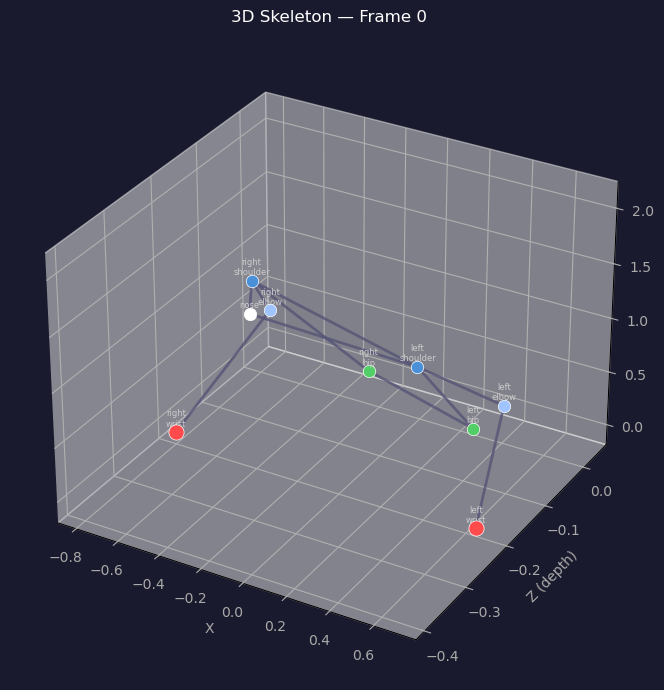

In [8]:
# Change this to inspect a different frame
FRAME_IDX = 0

# Colour map — local joint index → colour
JOINT_COLOURS = {
    0: 'white',    # nose
    1: '#4A90D9',  # left_shoulder  — blue
    2: '#4A90D9',  # right_shoulder — blue
    3: '#A0C4FF',  # left_elbow     — light blue
    4: '#A0C4FF',  # right_elbow    — light blue
    5: '#FF4B4B',  # left_wrist     — red
    6: '#FF4B4B',  # right_wrist    — red
    7: '#51CF66',  # left_hip       — green
    8: '#51CF66',  # right_hip      — green
}

frame = sequence[FRAME_IDX]   # (9, 3)

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

# Draw bones
for (i, j) in SKELETON_EDGES:
    xs = [frame[i, 0], frame[j, 0]]
    ys = [frame[i, 1], frame[j, 1]]
    zs = [frame[i, 2], frame[j, 2]]
    ax.plot(xs, zs, ys, color='#555577', linewidth=2, alpha=0.8)

# Draw joints
for j in range(NUM_ACTIVE_JOINTS):
    x, y, z = frame[j]
    colour   = JOINT_COLOURS[j]
    size     = 120 if j in [5, 6] else 80  # wrists larger
    ax.scatter(x, z, y, c=colour, s=size, zorder=5,
               edgecolors='white', linewidths=0.5)
    ax.text(x, z, y + 0.05,
            ACTIVE_JOINT_NAMES[j].replace('_', '\n'),
            fontsize=6, color='#cccccc', ha='center')

ax.set_xlabel('X', color='#aaaaaa')
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.set_zlabel('Y', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.set_title(f'3D Skeleton — Frame {FRAME_IDX}', color='white', pad=15)

plt.tight_layout()
plt.show()

## Cell 2 — Wrist Trajectories Over Time

X, Y, Z position of both wrists across all frames.
Punch delivery shows as a sharp spike in X or Z.

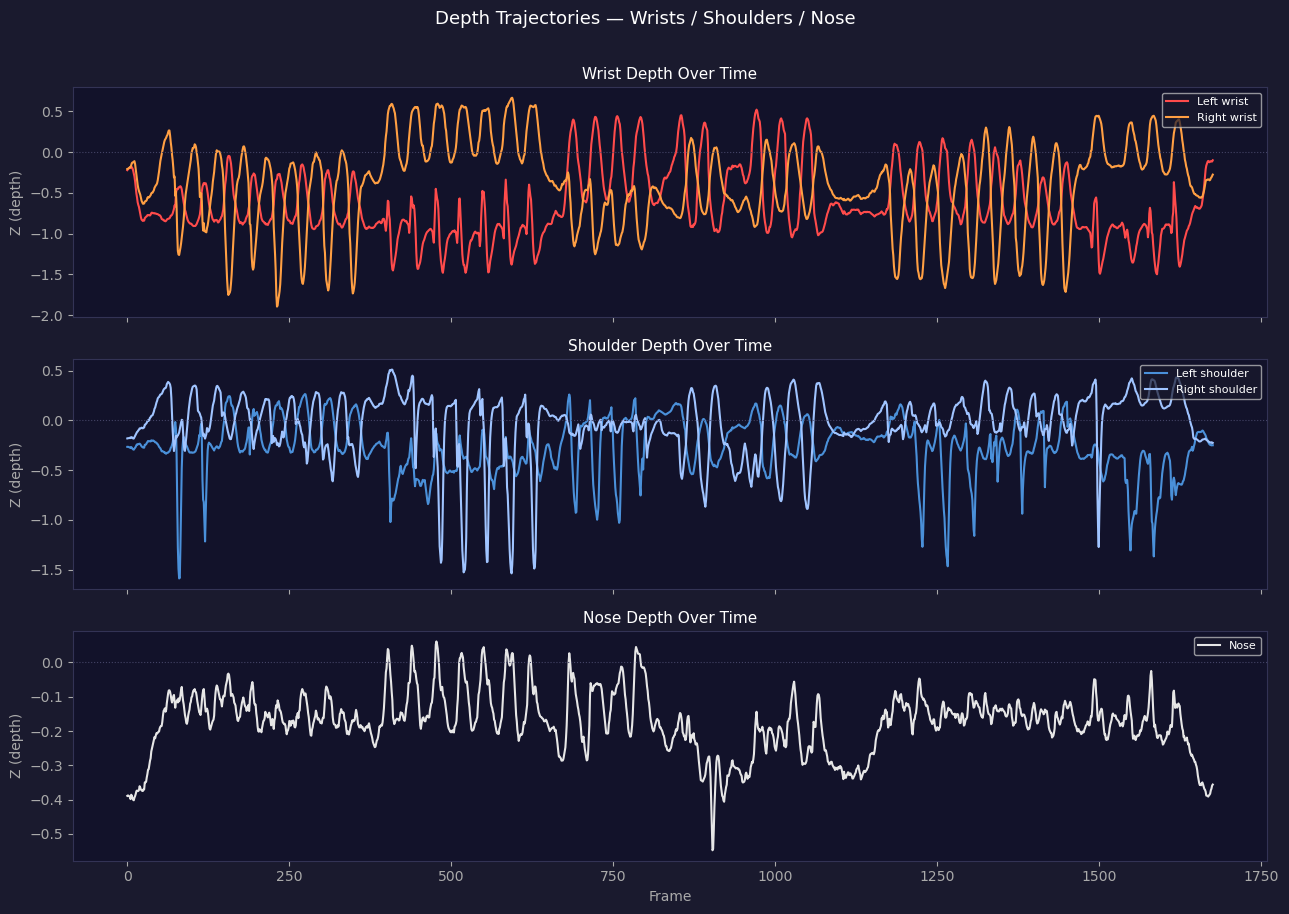

In [9]:
# Local joint indices
NOSE = 0
L_WRIST = 5
R_WRIST = 6
L_SHOULDER = 1
R_SHOULDER = 2

frames = np.arange(T)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.patch.set_facecolor('#1a1a2e')

colours = {
    'left_wrist':    '#FF4B4B',
    'right_wrist':   '#FF9F43',
    'left_shoulder': '#4A90D9',
    'right_shoulder':'#A0C4FF',
    'nose':          '#E6E6E6',
}

# 1) Wrist depth (Z)
ax = axes[0]
ax.set_facecolor('#12122a')
ax.plot(frames, sequence[:, L_WRIST, 2],
        color=colours['left_wrist'], linewidth=1.5, label='Left wrist')
ax.plot(frames, sequence[:, R_WRIST, 2],
        color=colours['right_wrist'], linewidth=1.5, label='Right wrist')
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.legend(loc='upper right', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Wrist Depth Over Time', color='white', fontsize=11)

# 2) Shoulder depth (Z)
ax = axes[1]
ax.set_facecolor('#12122a')
ax.plot(frames, sequence[:, L_SHOULDER, 2],
        color=colours['left_shoulder'], linewidth=1.5, label='Left shoulder')
ax.plot(frames, sequence[:, R_SHOULDER, 2],
        color=colours['right_shoulder'], linewidth=1.5, label='Right shoulder')
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.legend(loc='upper right', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Shoulder Depth Over Time', color='white', fontsize=11)

# 3) Nose depth (Z)
ax = axes[2]
ax.set_facecolor('#12122a')
ax.plot(frames, sequence[:, NOSE, 2],
        color=colours['nose'], linewidth=1.5, label='Nose')
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.legend(loc='upper right', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Nose Depth Over Time', color='white', fontsize=11)

axes[-1].set_xlabel('Frame', color='#aaaaaa')
fig.suptitle('Depth Trajectories — Wrists / Shoulders / Nose',
             color='white', fontsize=13, y=1.01)

plt.tight_layout()
plt.show()

## Cell 2B — Camera-Relative Trajectories
Same plots as Cell 2, but using the camera-space sequence (_camera.npy).

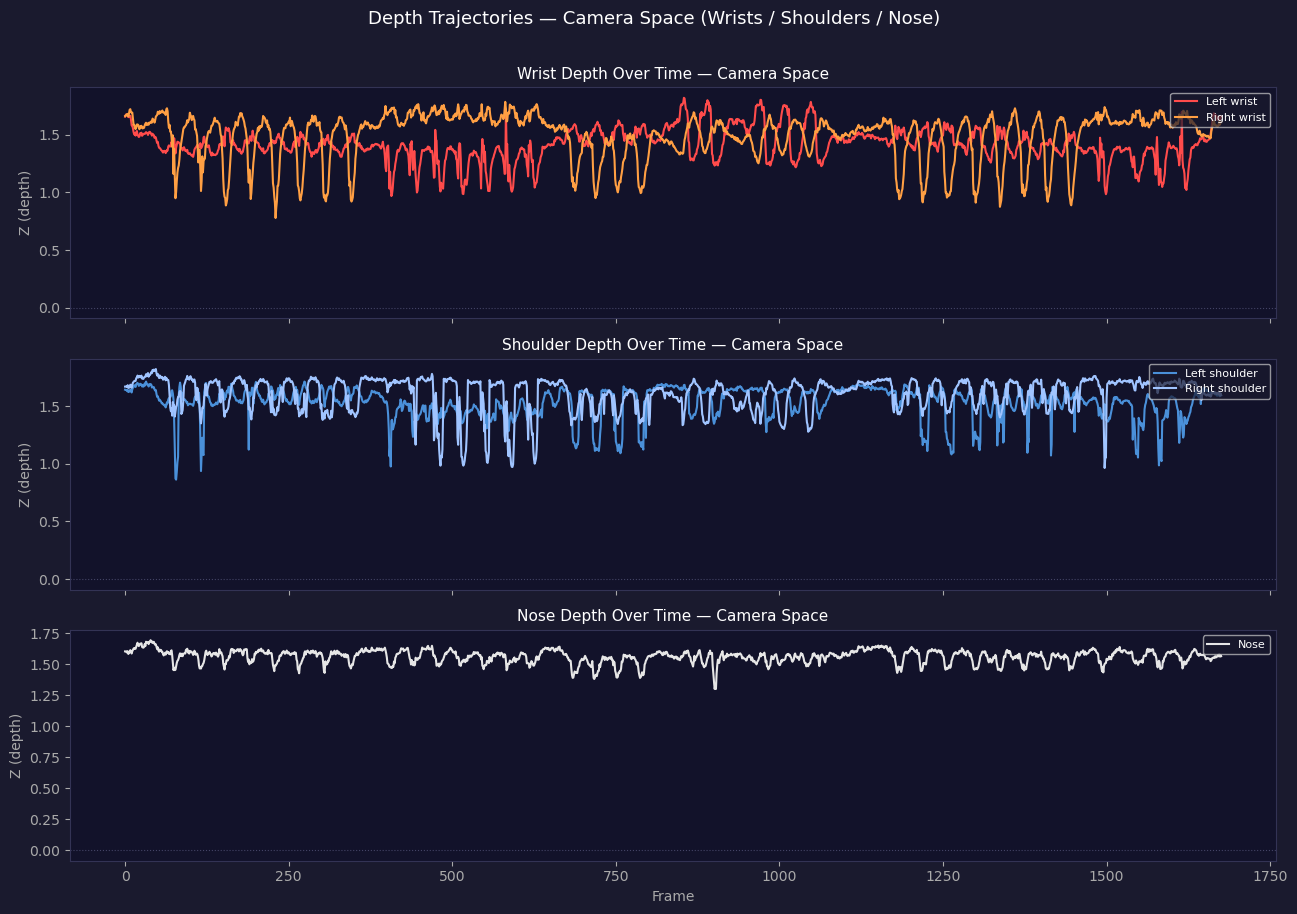

In [10]:
frames_cam = np.arange(camera_T)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.patch.set_facecolor('#1a1a2e')

# 1) Wrist depth (Z) — camera space
ax = axes[0]
ax.set_facecolor('#12122a')
ax.plot(frames_cam, camera_seq[:, L_WRIST, 2],
        color=colours['left_wrist'], linewidth=1.5, label='Left wrist')
ax.plot(frames_cam, camera_seq[:, R_WRIST, 2],
        color=colours['right_wrist'], linewidth=1.5, label='Right wrist')
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.legend(loc='upper right', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Wrist Depth Over Time — Camera Space', color='white', fontsize=11)

# 2) Shoulder depth (Z) — camera space
ax = axes[1]
ax.set_facecolor('#12122a')
ax.plot(frames_cam, camera_seq[:, L_SHOULDER, 2],
        color=colours['left_shoulder'], linewidth=1.5, label='Left shoulder')
ax.plot(frames_cam, camera_seq[:, R_SHOULDER, 2],
        color=colours['right_shoulder'], linewidth=1.5, label='Right shoulder')
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.legend(loc='upper right', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Shoulder Depth Over Time — Camera Space', color='white', fontsize=11)

# 3) Nose depth (Z) — camera space
ax = axes[2]
ax.set_facecolor('#12122a')
ax.plot(frames_cam, camera_seq[:, NOSE, 2],
        color=colours['nose'], linewidth=1.5, label='Nose')
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.legend(loc='upper right', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Nose Depth Over Time — Camera Space', color='white', fontsize=11)

axes[-1].set_xlabel('Frame', color='#aaaaaa')
fig.suptitle('Depth Trajectories — Camera Space (Wrists / Shoulders / Nose)',
             color='white', fontsize=13, y=1.01)

plt.tight_layout()
plt.show()

## Cell 3 — Joint Position Table

Raw XYZ coordinates for the first 5 frames.
Confirms the numbers are real and the pipeline ran correctly.

In [11]:
N_FRAMES = 5   # change to inspect more frames

# Header
col_w  = 10
header = f"{'Joint':<18}" + "".join(
    [f"{'Frame '+str(i):>{col_w*3}}" for i in range(N_FRAMES)]
)
subhdr = f"{'':18}" + "".join(
    [f"{'X':>{col_w}}{'Y':>{col_w}}{'Z':>{col_w}}" for _ in range(N_FRAMES)]
)

print(header)
print(subhdr)
print('-' * (18 + col_w * 3 * N_FRAMES))

for j in range(NUM_ACTIVE_JOINTS):
    name    = ACTIVE_JOINT_NAMES[j]
    marker  = ' ◀' if j in [5, 6] else ''   # highlight wrists
    row     = f"{name + marker:<18}"
    for t in range(N_FRAMES):
        x, y, z = sequence[t, j]
        row += f"{x:>{col_w}.3f}{y:>{col_w}.3f}{z:>{col_w}.3f}"
    print(row)

print('-' * (18 + col_w * 3 * N_FRAMES))
print(f'\nTotal frames in sequence: {T}')
print(f'Output shape: {sequence.shape}  →  (T, 9 joints, 3 axes)')

Joint                                    Frame 0                       Frame 1                       Frame 2                       Frame 3                       Frame 4
                           X         Y         Z         X         Y         Z         X         Y         Z         X         Y         Z         X         Y         Z
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
nose                  -0.016     2.083    -0.389    -0.015     2.084    -0.388    -0.017     2.085    -0.389    -0.019     2.081    -0.391    -0.021     2.078    -0.392
left_shoulder          0.489     1.488    -0.265     0.489     1.489    -0.265     0.489     1.489    -0.267     0.487     1.486    -0.270     0.487     1.482    -0.272
right_shoulder        -0.453     1.463    -0.181    -0.453     1.465    -0.178    -0.452     1.466    -0.178    -0.453     1.463    -0.177    -0.455     1.

---
## Kinematic Features — Force-Ready Dataset

Load the `_force_ready.npz` and inspect the three kinematic feature streams extracted by `src/features.py`.

In [ ]:
NPZ_PATH = '../data/processed/punch_iphone13_2_kinematics.npz'

force_data      = np.load(NPZ_PATH)
velocity_3d     = force_data['velocity_3d']      # (T, 2, 3) — left/right wrist, m/s
acceleration_3d = force_data['acceleration_3d']  # (T, 2, 3) — left/right wrist, m/s²
elbow_angle_deg = force_data['elbow_angle_deg']  # (T, 2)    — degrees

print(f'Loaded  : {NPZ_PATH}')
print(f'Arrays  : {list(force_data.files)}')
print(f'velocity_3d     : {velocity_3d.shape}   min={velocity_3d.min():.3f}  max={velocity_3d.max():.3f} m/s')
print(f'acceleration_3d : {acceleration_3d.shape}   min={acceleration_3d.min():.3f}  max={acceleration_3d.max():.3f} m/s²')
print(f'elbow_angle_deg : {elbow_angle_deg.shape}   min={elbow_angle_deg.min():.1f}°  max={elbow_angle_deg.max():.1f}°')
print()
print('Axis legend for velocity_3d / acceleration_3d:')
print('  [:, 0, :] = left wrist   |  [:, 1, :] = right wrist')
print('  [:, :, 0] = X   [:, :, 1] = Y   [:, :, 2] = Z (depth)')

## Cell 4 — Z-Velocity & Z-Acceleration (Punch Snap)

Derived from the smoothed wrist Z stream via Savitzky-Golay differentiation.

- **Z-Velocity** — rate of depth change in shoulder-width units/s. A punch toward the camera produces a **negative spike** (wrist Z decreasing = moving closer).
- **Z-Acceleration** — rate of velocity change. The **zero-crossing** (negative→positive) marks the moment of peak punch extension / impact.

Both use the same SG window and polynomial order as the smoothing step.

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.patch.set_facecolor('#1a1a2e')

# ── Z-Velocity ────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#12122a')
ax.plot(frames, velocity_3d[:, 0, 2], color='#FF4B4B', linewidth=1.5, label='Left wrist')
ax.plot(frames, velocity_3d[:, 1, 2], color='#FF9F43', linewidth=1.5, label='Right wrist')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.set_ylabel('Z-Velocity (m/s)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.legend(loc='upper right', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Wrist Z-Velocity  —  negative spike = punch toward camera',
             color='white', fontsize=11)

# ── Z-Acceleration ────────────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor('#12122a')
ax.plot(frames, acceleration_3d[:, 0, 2], color='#FF4B4B', linewidth=1.5, label='Left wrist')
ax.plot(frames, acceleration_3d[:, 1, 2], color='#FF9F43', linewidth=1.5, label='Right wrist')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.set_ylabel('Z-Acceleration (m/s²)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.legend(loc='upper right', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Wrist Z-Acceleration  —  zero-crossing marks punch impact',
             color='white', fontsize=11)

axes[-1].set_xlabel('Frame', color='#aaaaaa')
fig.suptitle('Kinematic Evidence — Wrist Z-Velocity & Z-Acceleration (metric)',
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Cell 5 — Elbow Angle (Arm Extension)

3D angle at each elbow computed via dot product on the Shoulder → Elbow → Wrist vectors.

- **Jab / straight punch** → near full extension (~180°)
- **Hook / uppercut** → stays bent (<120°)

Angles are in degrees. Frames where a joint was occluded show as 0°.

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#12122a')

ax.plot(frames, elbow_angle_deg[:, 0], color='#4A90D9', linewidth=1.5, label='Left elbow')
ax.plot(frames, elbow_angle_deg[:, 1], color='#A0C4FF', linewidth=1.5, label='Right elbow')
ax.axhline(180, color='#51CF66', linewidth=0.8, linestyle=':', label='Full extension (180°)')

ax.set_ylabel('Elbow Angle (°)', color='#aaaaaa')
ax.set_xlabel('Frame', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.set_ylim(0, 200)
ax.legend(loc='upper right', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Elbow Angle Over Time  —  jab ≈ 180°, hook < 120°',
             color='white', fontsize=11)

fig.suptitle('3D Elbow Angle (Shoulder → Elbow → Wrist)',
             color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()